# ConvNeXt-Large Plotting

This notebook generates publication-ready plots for the DeathScope ConvNeXt-Large classifier training run.

Expected inputs from the training notebook:
- `history.json` or `history.csv`
- `final_metrics.json`
- optional `classes.json`

Outputs are written to `PLOTS_DIR` as high-resolution PNG, TIFF, and SVG figures suitable for manuscript preparation and slide use.


In [1]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_repo_root() -> Path:
    candidate = Path.cwd().resolve()
    while candidate != candidate.parent and not (candidate / "pyproject.toml").exists():
        candidate = candidate.parent
    if not (candidate / "pyproject.toml").exists():
        raise FileNotFoundError("Could not locate the repository root containing pyproject.toml.")
    return candidate


repo_root = find_repo_root()
print(f"Repository root: {repo_root}")


Repository root: /media/capp/TMP2/DeathScope


## Configuration

By default, the notebook targets the artifact directory used by `ConvNeXt-Large_training.ipynb`.


In [2]:
RUN_DIR = repo_root / "training/ConvNeXt"
PLOTS_DIR = RUN_DIR / "plots"
HISTORY_JSON = RUN_DIR / "history.json"
HISTORY_CSV = RUN_DIR / "history.csv"
FINAL_METRICS_JSON = RUN_DIR / "final_metrics.json"
CLASSES_JSON = RUN_DIR / "classes.json"

DPI = 600
SAVE_FORMATS = ("png", "tiff", "svg")
FIG_FACE_COLOR = "white"
PALETTE = {
    "train": "#1b5e20",
    "val": "#c62828",
    "auc": "#1565c0",
    "bar": "#455a64",
}

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run directory:   {RUN_DIR}")
print(f"Plots directory: {PLOTS_DIR}")


Run directory:   /media/capp/TMP2/DeathScope/training/ConvNeXt
Plots directory: /media/capp/TMP2/DeathScope/training/ConvNeXt/plots


## Load Artifacts

The notebook accepts either `history.json` or `history.csv`. It also reads `final_metrics.json` for summary statistics and the confusion matrix.


In [3]:
def load_history(history_json: Path, history_csv: Path) -> pd.DataFrame:
    if history_json.is_file():
        with history_json.open("r", encoding="utf-8") as file:
            payload = json.load(file)
        history = pd.DataFrame(payload)
    elif history_csv.is_file():
        history = pd.read_csv(history_csv)
    else:
        raise FileNotFoundError(
            f"Neither history file exists: {history_json} or {history_csv}. Run the training notebook first."
        )

    required_columns = {
        "epoch",
        "train_loss",
        "train_acc",
        "train_f1",
        "val_loss",
        "val_acc",
        "val_f1",
        "val_auc",
    }
    missing = required_columns.difference(history.columns)
    if missing:
        raise ValueError(f"History file is missing required columns: {sorted(missing)}")

    history = history.sort_values("epoch").reset_index(drop=True)
    return history


def load_json(path: Path) -> dict:
    if not path.is_file():
        raise FileNotFoundError(f"Required file not found: {path}")
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def normalize_class_mapping(final_metrics: dict, classes_payload: dict | None) -> dict[int, str]:
    if "classes" in final_metrics and isinstance(final_metrics["classes"], dict):
        return {int(index): str(label) for index, label in final_metrics["classes"].items()}
    if classes_payload and "idx_to_class" in classes_payload:
        return {int(index): str(label) for index, label in classes_payload["idx_to_class"].items()}
    return {0: "class_0", 1: "class_1"}


history_df = load_history(HISTORY_JSON, HISTORY_CSV)
final_metrics = load_json(FINAL_METRICS_JSON)
classes_payload = load_json(CLASSES_JSON) if CLASSES_JSON.is_file() else None
idx_to_class = normalize_class_mapping(final_metrics, classes_payload)

summary_df = pd.DataFrame([
    {
        "best_epoch": final_metrics.get("best_epoch"),
        "val_loss": final_metrics.get("val_loss"),
        "val_acc": final_metrics.get("val_acc"),
        "val_f1": final_metrics.get("val_f1"),
        "val_auc": final_metrics.get("val_auc"),
    }
])

display(summary_df)
display(history_df.tail())
print(f"Class mapping: {idx_to_class}")


,best_epoch,val_loss,val_acc,val_f1,val_auc
0,39,0.330636,0.925816,0.938575,0.977373


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,val_auc,lr,seconds
75,76,0.117782,0.999753,0.999791,0.362754,0.917903,0.932245,0.970377,6.155830e-07,40.987176
76,77,0.119001,0.999258,0.999375,0.361649,0.916914,0.931373,0.971052,3.465772e-07,41.024178
77,78,0.120204,0.998764,0.998958,0.359715,0.916914,0.931034,0.971654,1.541333e-07,41.579475
78,79,0.117667,0.999753,0.999791,0.360281,0.916914,0.931034,0.971688,3.854819e-08,40.919998
79,80,0.117481,0.999505,0.999583,0.360347,0.916914,0.931034,0.971686,0.000000e+00,41.161799


Class mapping: {0: 'apoptosis', 1: 'pyroptosis'}


## Plot Helpers

These helpers standardize figure styling and save each figure in all requested output formats.


In [4]:
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update(
    {
        "figure.facecolor": FIG_FACE_COLOR,
        "axes.facecolor": FIG_FACE_COLOR,
        "savefig.facecolor": FIG_FACE_COLOR,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def save_figure(fig: plt.Figure, stem: str) -> None:
    for suffix in SAVE_FORMATS:
        fig.savefig(PLOTS_DIR / f"{stem}.{suffix}", dpi=DPI, bbox_inches="tight")


def add_panel_label(ax: plt.Axes, label: str) -> None:
    ax.text(
        -0.14,
        1.06,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="left",
    )


## Training Curves

This panel summarizes optimization dynamics over the full run.


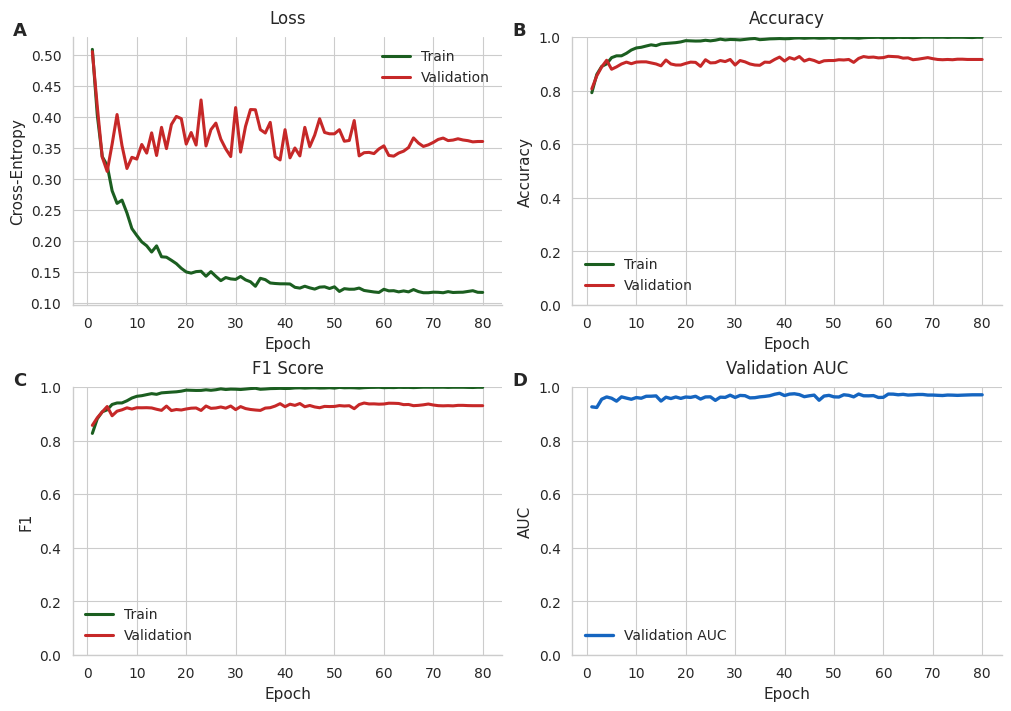

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
axes = axes.ravel()
epochs = history_df["epoch"]

axes[0].plot(epochs, history_df["train_loss"], color=PALETTE["train"], linewidth=2.2, label="Train")
axes[0].plot(epochs, history_df["val_loss"], color=PALETTE["val"], linewidth=2.2, label="Validation")
axes[0].set_title("Loss",pad=10)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend(frameon=False)
add_panel_label(axes[0], "A")

axes[1].plot(epochs, history_df["train_acc"], color=PALETTE["train"], linewidth=2.2, label="Train")
axes[1].plot(epochs, history_df["val_acc"], color=PALETTE["val"], linewidth=2.2, label="Validation")
axes[1].set_title("Accuracy", pad=10)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].legend(frameon=False)
add_panel_label(axes[1], "B")

axes[2].plot(epochs, history_df["train_f1"], color=PALETTE["train"], linewidth=2.2, label="Train")
axes[2].plot(epochs, history_df["val_f1"], color=PALETTE["val"], linewidth=2.2, label="Validation")
axes[2].set_title("F1 Score", pad=10)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1")
axes[2].set_ylim(0.0, 1.0)
axes[2].legend(frameon=False)
add_panel_label(axes[2], "C")

axes[3].plot(epochs, history_df["val_auc"], color=PALETTE["auc"], linewidth=2.4, label="Validation AUC")
axes[3].set_title("Validation AUC", pad=10)
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("AUC")
axes[3].set_ylim(0.0, 1.0)
axes[3].legend(frameon=False)
add_panel_label(axes[3], "D")

save_figure(fig, "training_curves")
plt.show()


## Final Metrics

This figure gives a compact view of the best validation metrics written by the training notebook.


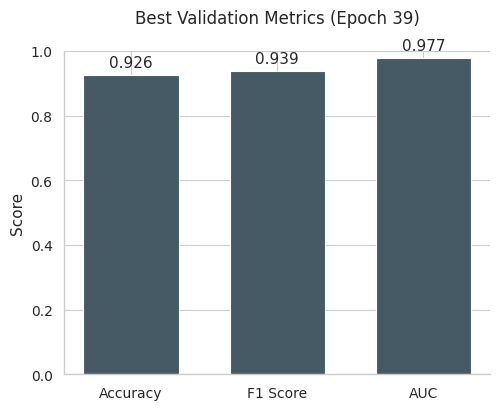

In [6]:
metric_order = ["val_acc", "val_f1", "val_auc"]
metric_labels = {
    "val_acc": "Accuracy",
    "val_f1": "F1 Score",
    "val_auc": "AUC",
}
metric_values = [float(final_metrics[key]) for key in metric_order]
metric_frame = pd.DataFrame(
    {"Metric": [metric_labels[key] for key in metric_order], "Score": metric_values}
)

fig, ax = plt.subplots(figsize=(5.5, 4.2))
bars = ax.bar(metric_frame["Metric"], metric_frame["Score"], color=PALETTE["bar"], width=0.65)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Score")
ax.set_title(f"Best Validation Metrics (Epoch {final_metrics['best_epoch']})", pad=20)
for bar, value in zip(bars, metric_frame["Score"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f"{value:.3f}", ha="center", va="bottom")

save_figure(fig, "final_metrics_barplot")
plt.show()


## Confusion Matrix

If `final_metrics.json` contains a confusion matrix, the notebook renders a publication-ready heatmap.


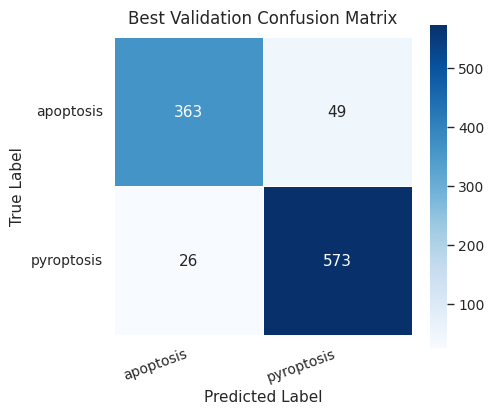

In [7]:
confusion_matrix = final_metrics.get("confusion_matrix")
if confusion_matrix is None:
    print("No confusion matrix found in final_metrics.json; skipping this figure.")
else:
    conf = np.asarray(confusion_matrix, dtype=np.int64)
    labels = [idx_to_class[index] for index in sorted(idx_to_class)]

    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    sns.heatmap(
        conf,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        square=True,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title("Best Validation Confusion Matrix",pad=10)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)

    save_figure(fig, "confusion_matrix")
    plt.show()


## Export Summary

This final cell records the plot inventory for quick inspection and downstream packaging.


In [8]:
plot_files = sorted(PLOTS_DIR.glob("*"))
plot_index = pd.DataFrame(
    [{"filename": path.name, "suffix": path.suffix, "bytes": path.stat().st_size} for path in plot_files]
)
display(plot_index)
print(f"Saved {len(plot_files)} plot files to {PLOTS_DIR}")


,filename,suffix,bytes
0,confusion_matrix.png,.png,216465
1,confusion_matrix.svg,.svg,33841
2,confusion_matrix.tiff,.tiff,29444714
3,final_metrics_barplot.png,.png,151818
4,final_metrics_barplot.svg,.svg,26366
5,final_metrics_barplot.tiff,.tiff,29455830
6,training_curves.png,.png,671049
7,training_curves.svg,.svg,79835
8,training_curves.tiff,.tiff,103634450


Saved 9 plot files to /media/capp/TMP2/DeathScope/training/ConvNeXt/plots
